# Recognize Handwritten Digits Using a Deep Neural Network

In [2]:
# Task1: Import Modules
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
from time import time
from torchvision import datasets, transforms
from torch import nn, optim

In [3]:
# Task 2: Create a Transformation
normalized = transforms.Normalize((0.5,), (0.5,))
tensor = transforms.ToTensor()
transformation = transforms.Compose([tensor, normalized])

In [4]:
# Task 3: Download and Load Datasets
training_dataset = datasets.MNIST('handwritten_digits/data/.', download=True, train=True, transform=transformation)
testing_dataset = datasets.MNIST('handwritten_digits/data/.', download=True, train=False, transform=transformation)

train_data = torch.utils.data.DataLoader(training_dataset, batch_size=64, shuffle=True)
test_data = torch.utils.data.DataLoader(testing_dataset, batch_size=64, shuffle=True)

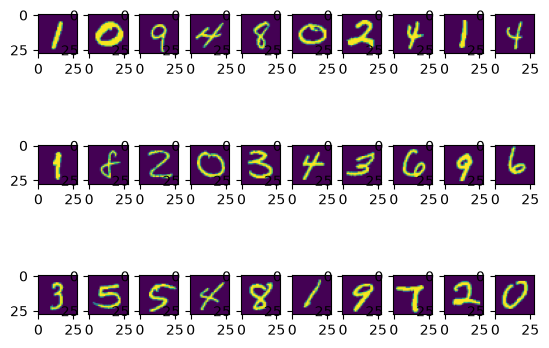

In [5]:
# Task 4: Visualize Images
images, labels = next(iter(train_data))
for i in range(1, 31):
    plt.subplot(3,10, i)
    plt.subplots_adjust(wspace=0.3)
    plt.imshow(images[i].numpy().squeeze())

In [14]:
# Task 5: Calculate Size of Layers
input_layer = 784
hidden_layer1 = 64
hidden_layer2 = 32
output_layer = 10

In [15]:
# Task 6: Build a Model
model = nn.Sequential(nn.Linear(input_layer, hidden_layer1),
nn.ReLU(),
nn.Linear(hidden_layer1,hidden_layer2),
nn.ReLU(),
nn.Linear(hidden_layer2, output_layer))

In [16]:
# Task 7: Calculate Cross-Entropy Loss
images = images.view(images.shape[0], -1)
outputs = model(images)
lossFunction = nn.CrossEntropyLoss()
loss = lossFunction(outputs, labels)

In [17]:
# Task 8: Obtain the Stochastic Gradient Descent Optimizer
gradient_descent = optim.SGD(model.parameters(), lr=0.1)

In [18]:
# Task 9: Train the Model
epochs = 20
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_data:
        images = images.view(images.shape[0], -1)
        # Feed-Forward
        gradient_descent.zero_grad()
        loss = lossFunction(model(images), labels)
        # Back Propagation
        loss.backward()
        # Optimize the weights
        gradient_descent.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(labels)
    print("Iteration : ", epoch+1, end = "\t")
    print("Loss: ", epoch_loss)

Iteration :  1	Loss:  929.2980793863535
Iteration :  2	Loss:  387.71086727641523
Iteration :  3	Loss:  290.81794832646847
Iteration :  4	Loss:  240.1002596858889
Iteration :  5	Loss:  210.38689982704818
Iteration :  6	Loss:  187.4837593352422
Iteration :  7	Loss:  170.17979517765343
Iteration :  8	Loss:  159.54238003923092
Iteration :  9	Loss:  144.9064806238748
Iteration :  10	Loss:  134.54732066206634
Iteration :  11	Loss:  122.95466707460582
Iteration :  12	Loss:  119.04168150271289
Iteration :  13	Loss:  113.77274458378088
Iteration :  14	Loss:  102.57819849660154
Iteration :  15	Loss:  98.15697472263128
Iteration :  16	Loss:  91.41381163080223
Iteration :  17	Loss:  87.64484900282696
Iteration :  18	Loss:  84.00051577587146
Iteration :  19	Loss:  79.22995813575108
Iteration :  20	Loss:  74.57106130965985


In [19]:
# Task 10: Get the Predicted Label
def get_predicted_label(image):
    image = image.view(1, 28*28)
    with torch.no_grad():
        prediction_score = model(image)
    return np.argmax(prediction_score)

In [20]:
# Task 10: Test the Prediction Method
images, labels = next(iter(test_data))
print("Predicted Label: ", 
get_predicted_label(images[0]))
print("Actual Label: ", labels.numpy()[0])

Predicted Label:  tensor(7)
Actual Label:  7


In [21]:
# Task 11: Test the Model
totalCount = 0
accurateCount = 0
for images, labels in test_data:
    for i in range(len(labels)):
        predictedLabel = get_predicted_label(images[i])
        actualLabel = labels.numpy()[i]
        print("Predicted Label: ", predictedLabel, " / Actual Label: ", actualLabel)
        if(predictedLabel == actualLabel):
            accurateCount += 1
    totalCount += len(labels)
print("Total images tested: : ", totalCount)
print("Accurate predictions: ", accurateCount)
print("Accuracy percentage: ", ((accurateCount/totalCount)*100), "%")

Predicted Label:  tensor(3)  / Actual Label:  3
Predicted Label:  tensor(9)  / Actual Label:  9
Predicted Label:  tensor(3)  / Actual Label:  3
Predicted Label:  tensor(2)  / Actual Label:  2
Predicted Label:  tensor(7)  / Actual Label:  7
Predicted Label:  tensor(2)  / Actual Label:  2
Predicted Label:  tensor(8)  / Actual Label:  8
Predicted Label:  tensor(4)  / Actual Label:  4
Predicted Label:  tensor(0)  / Actual Label:  0
Predicted Label:  tensor(9)  / Actual Label:  9
Predicted Label:  tensor(6)  / Actual Label:  6
Predicted Label:  tensor(8)  / Actual Label:  8
Predicted Label:  tensor(7)  / Actual Label:  7
Predicted Label:  tensor(6)  / Actual Label:  6
Predicted Label:  tensor(8)  / Actual Label:  8
Predicted Label:  tensor(2)  / Actual Label:  2
Predicted Label:  tensor(0)  / Actual Label:  0
Predicted Label:  tensor(1)  / Actual Label:  1
Predicted Label:  tensor(2)  / Actual Label:  2
Predicted Label:  tensor(0)  / Actual Label:  0
Predicted Label:  tensor(1)  / Actual La